In [1]:
!pip install yfinance tensorflow scikit-learn matplotlib

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [16]:
ticker = "AAPL"  # Change this to any stock (e.g., TSLA, MSFT, INFY)
df = yf.download(ticker, start="2015-01-01", end="2025-01-01")

/tmp/ipython-input-3517730602.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [4]:
print(df.head())

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.261044  24.729267  23.821668  24.718171  212818400
2015-01-05  23.577574  24.110150  23.391173  24.030263  257142000
2015-01-06  23.579792  23.839422  23.218083  23.641926  263188400
2015-01-07  23.910437  24.010294  23.677434  23.788387  160423600
2015-01-08  24.829130  24.886826  24.121248  24.238859  237458000


In [5]:
data = df['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

training_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:training_size]
test_data = scaled_data[training_size-60:]


In [6]:
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)


In [7]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [8]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0204 - val_loss: 0.0030
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 9.7752e-04 - val_loss: 0.0022
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 8.6225e-04 - val_loss: 0.0033
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 8.5733e-04 - val_loss: 0.0034
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 7.0841e-04 - val_loss: 0.0014
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 6.8736e-04 - val_loss: 8.1706e-04
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 7.4200e-04 - val_loss: 0.0013
Epoch 9/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 6.6818e-04 - val_loss: 5.9718e-04
Epoch 10/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 5.3425e-04 - val_loss: 0.0017
Epoch 11/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 5.4296e-04 - val_loss: 0.0011
Epoch 12/20
61/61 ━

In [17]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


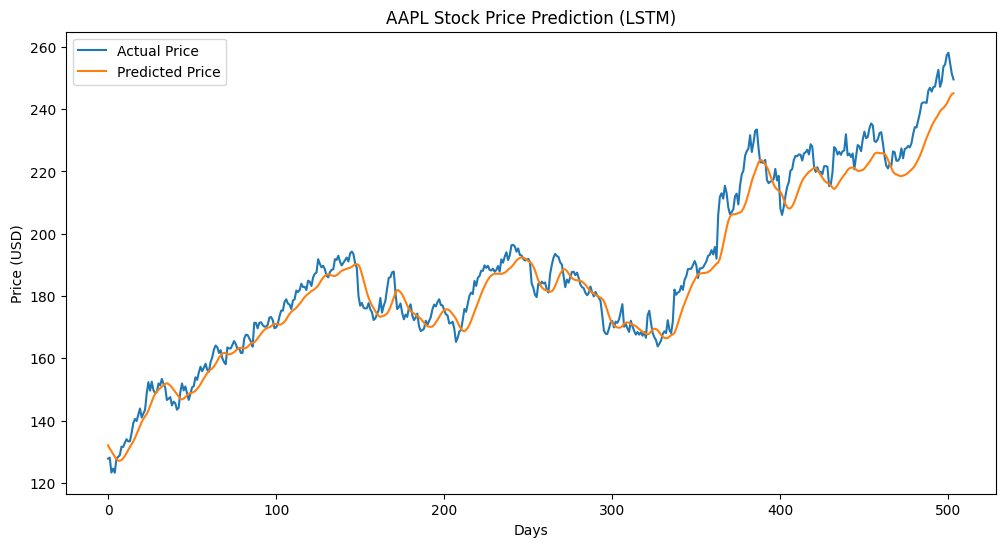

In [18]:
plt.figure(figsize=(12,6))
plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title(f"{ticker} Stock Price Prediction (LSTM)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()